In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("normal_data_clean.csv", header=None)
df.columns = ['ax_g', 'ay_g', 'az_g', 'accel_magnitude']
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
df.to_csv("normal_data_clean.csv", index=False)

In [3]:
df = pd.read_csv("disturbed_data_clean.csv", header=None)
df.columns = ['ax_g', 'ay_g', 'az_g', 'accel_magnitude']
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
df.to_csv("disturbed_data_clean.csv", index=False)

In [4]:
df = pd.read_csv("normal_data_clean.csv")
print(df.columns)
print(df.dtypes)

Index(['ax_g', 'ay_g', 'az_g', 'accel_magnitude'], dtype='object')
ax_g               float64
ay_g               float64
az_g               float64
accel_magnitude    float64
dtype: object


In [5]:
df = pd.read_csv("disturbed_data_clean.csv")
print(df.columns)
print(df.dtypes)

Index(['ax_g', 'ay_g', 'az_g', 'accel_magnitude'], dtype='object')
ax_g               float64
ay_g               float64
az_g               float64
accel_magnitude    float64
dtype: object


In [6]:
df.head()

,ax_g,ay_g,az_g,accel_magnitude
0,-0.1377,0.8755,-0.4443,0.9914
1,-0.1279,0.8728,-0.4404,0.9860
2,-0.1316,0.8752,-0.4414,0.9890
3,-0.1375,0.8831,-0.4460,0.9988
4,-0.1289,0.8804,-0.4404,0.9928


In [7]:
# remove the first row of garbage value

In [8]:
df = pd.read_csv("normal_data_clean.csv")
df = df.iloc[1:].reset_index(drop=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
df.to_csv("normal_data_clean.csv", index=False)

In [9]:
df.head()

,ax_g,ay_g,az_g,accel_magnitude
0,-0.1211,0.8738,-0.4463,0.9886
1,-0.1162,0.8853,-0.4341,0.9928
2,-0.1216,0.8774,-0.4402,0.9892
3,-0.1223,0.8738,-0.4456,0.9884
4,-0.1150,0.8794,-0.4441,0.9919


In [10]:
df = pd.read_csv("disturbed_data_clean.csv")
df = df.iloc[1:].reset_index(drop=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)
df.to_csv("disturbed_data_clean.csv", index=False)

In [11]:
df.head()

,ax_g,ay_g,az_g,accel_magnitude
0,-0.1279,0.8728,-0.4404,0.9860
1,-0.1316,0.8752,-0.4414,0.9890
2,-0.1375,0.8831,-0.4460,0.9988
3,-0.1289,0.8804,-0.4404,0.9928
4,-0.1348,0.8716,-0.4424,0.9867


In [12]:
normal_df = pd.read_csv("normal_data_clean.csv")
disturbed_df = pd.read_csv("disturbed_data_clean.csv")

normal_signal = normal_df['accel_magnitude'].values
disturbed_signal = disturbed_df['accel_magnitude'].values

In [13]:
# Windowing function
def create_windows(signal,window_size,step_size):
    windows = []
    for start in range(0,len(signal)-window_size,step_size):
        windows.append(signal[start:start + window_size])
    return np.array(windows)

In [14]:
window_size = 100
step_size = 50

normal_windows = create_windows(normal_signal,window_size,step_size)
disturbed_windows = create_windows(disturbed_signal,window_size,step_size)

print(normal_windows.shape)
print(disturbed_windows.shape)

(39, 100)
(42, 100)


In [15]:
# feature function
def extract_features(signal):
    return{
        'mean': np.mean(signal),
        'std': np.std(signal),
        'var' : np.var(signal),
        'rms' : np.sqrt(np.mean(signal**2)),
        'max' : np.max(signal),
        'min' : np.min(signal)
    
    }

In [16]:
normal_features = [extract_features(w) for w in normal_windows]
disturbed_features = [extract_features(w) for w in disturbed_windows]

In [17]:
normal_feat = pd.DataFrame(normal_features)
normal_feat['label'] = 0

disturbed_feat = pd.DataFrame(disturbed_features)
disturbed_feat['label'] = 1

In [18]:
window_df = pd.concat(
    [normal_feat,disturbed_feat],
    ignore_index = True
)
window_df.head()

,mean,std,var,rms,max,min,label
0,0.991346,0.003564,0.000013,0.991352,1.0003,0.9833,0
1,0.990526,0.004023,0.000016,0.990534,1.0003,0.9811,0
2,0.990265,0.004023,0.000016,0.990273,0.9992,0.9811,0
3,0.990920,0.003942,0.000016,0.990928,1.0017,0.9814,0
4,0.991284,0.003972,0.000016,0.991292,1.0017,0.9824,0


In [19]:
window_df['label'].value_counts()

label
1    42
0    39
Name: count, dtype: int64

In [20]:
window_df.to_csv("window_features.csv",index=False)

In [21]:
winfeatures_df = pd.read_csv('window_features.csv')
winfeatures_df.head()

,mean,std,var,rms,max,min,label
0,0.991346,0.003564,0.000013,0.991352,1.0003,0.9833,0
1,0.990526,0.004023,0.000016,0.990534,1.0003,0.9811,0
2,0.990265,0.004023,0.000016,0.990273,0.9992,0.9811,0
3,0.990920,0.003942,0.000016,0.990928,1.0017,0.9814,0
4,0.991284,0.003972,0.000016,0.991292,1.0017,0.9824,0


In [22]:
#spliting the data into train and test
from sklearn.model_selection import train_test_split
np.random.seed(42)
X = winfeatures_df.drop('label',axis=1)
y = winfeatures_df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                test_size = 0.2,
                                                stratify = y)


In [23]:
# Training a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [24]:
model.score(X_test,y_test)

0.8823529411764706

In [25]:
# Making predictions
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1], dtype=int64)

In [26]:
# Evaluating accuracy and computing confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
cmat = confusion_matrix(y_test,y_pred)
print("Accuracy: ",accuracy)
print('Confusion Matrix:\n',cmat)

Accuracy:  0.8823529411764706
Confusion Matrix:
 [[8 0]
 [2 7]]


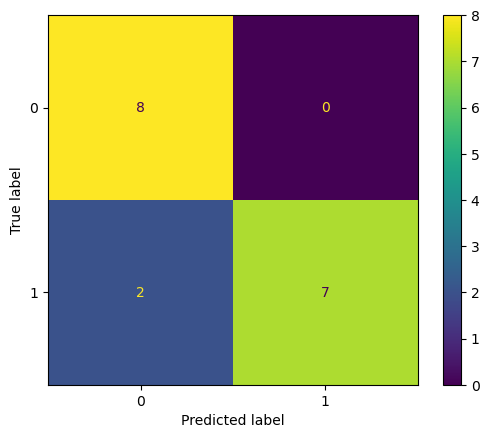

In [27]:
# Displaying Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

In [28]:
# From above Confusion Matrix we conclude that:
# Actual Normal = 8; Predicted Normal = 8
# Actual Disturbed = 9; Predicted Disturbed = 7

In [29]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.78      0.88         9

    accuracy                           0.88        17
   macro avg       0.90      0.89      0.88        17
weighted avg       0.91      0.88      0.88        17



In [30]:
# Finding which vibration feature is repsonsible for fault?

#1. Extract Feature importance
feature_importance = pd.Series(
    model.coef_[0],
    index = X.columns
)
feature_importance

mean    0.000775
std     0.514209
var     0.136579
rms     0.066646
max     2.271129
min    -1.419289
dtype: float64

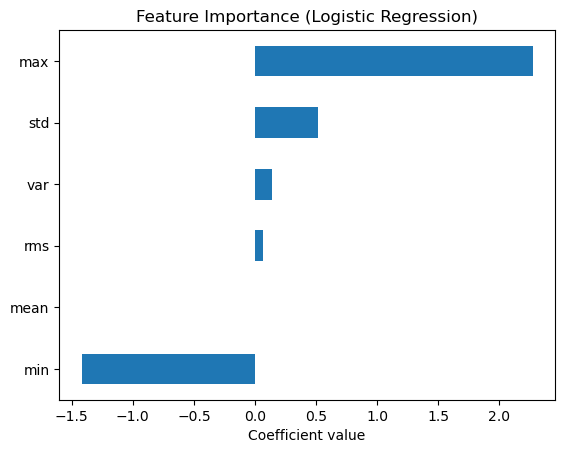

In [31]:
#2. Visualizing feature importance
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient value')
plt.show()

In [32]:
# from above plot we understand
# 1. max (strongest indicator) -> when maximum vibration amplitude increases, the probablity of disturbance increases significantly
# 2. min (strongest negative indicator) -> very low negative vibration also influence disturbance detection

In [33]:
# Comparison with other model i.e. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [34]:
rf_model.score(X_test,y_test)

1.0

In [35]:
rf_pred = rf_model.predict(X_test)

In [36]:
rf_pred

array([0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1], dtype=int64)

In [37]:
# Evaluating accuracy and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix
rf_accuracy = accuracy_score(y_test,rf_pred)
rf_cmat = confusion_matrix(y_test,rf_pred)
print("Random Forest accuracy: ",rf_accuracy)
print("Random Forest Confusion Matrix:\n",rf_cmat)

Random Forest accuracy:  1.0
Random Forest Confusion Matrix:
 [[8 0]
 [0 9]]


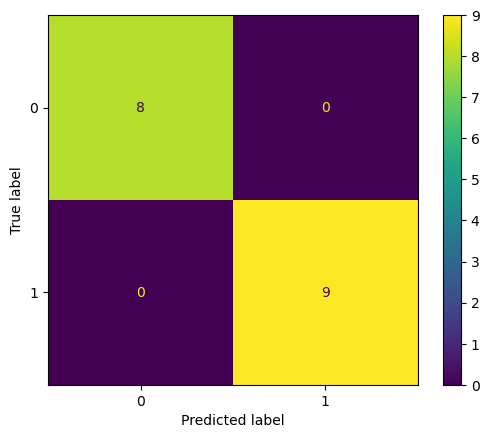

In [38]:
# Displaying Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,rf_pred)
plt.show()


In [39]:
# From above Confusion Matrix of Random Forest we conclude that:
# Actual Normal = 8; Predicted Normal = 8
# Actual Disturbed = 9; Predicted Disturbed = 9
# Thus, Random Forest performed better than Logistic regression 

In [40]:
# Classification report of Random Forest
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [41]:
# Finding which vibration feature is responsible for fault in random forest

# 1. Extract Feature importance
rf_feature_importance = pd.Series(
    rf_model.feature_importances_,
    index = X.columns
)
rf_feature_importance

mean    0.058364
std     0.283185
var     0.184645
rms     0.088643
max     0.161621
min     0.223542
dtype: float64

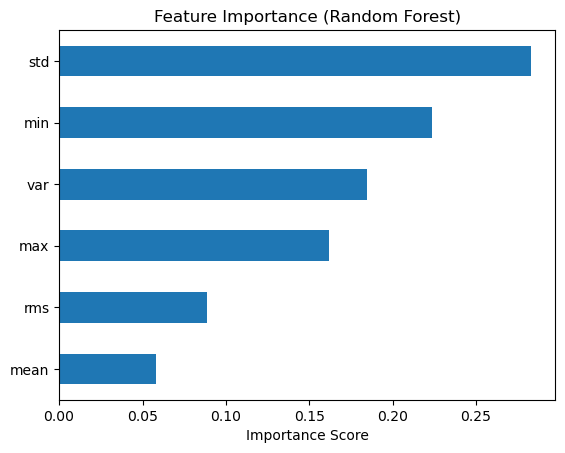

In [42]:
# Visualizing feature importance
rf_feature_importance.sort_values().plot(kind = 'barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel('Importance Score')
plt.show()

In [43]:
# From above plot we conclude
# Most important feature:
#1. std -> it is strongest signal for detecting disturbances, this is because when we disturb , vibration becomes more irregular that increases variation
#2. min -> Disturbances probably create sharp negative spikes in vibration

In [44]:
# Comparing both models
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[0.8823529411764706, 1.0]
}) 
comparison


,Model,Accuracy
0,Logistic Regression,0.882353
1,Random Forest,1.000000


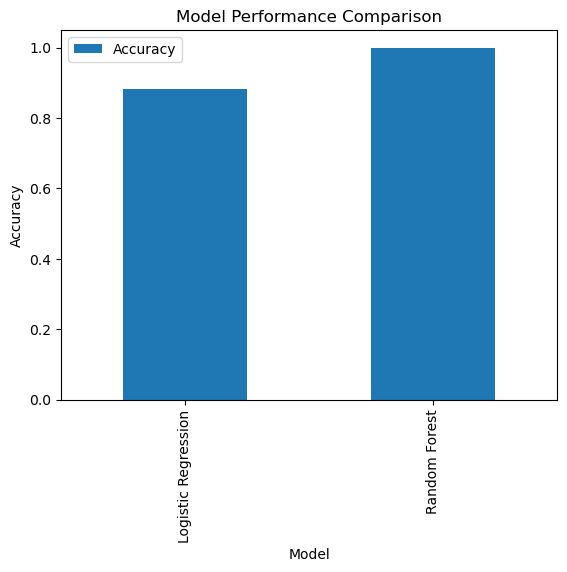

In [45]:
comparison.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.show()

In [46]:
import joblib
joblib.dump(rf_model, "predictive_maintenance_model.pkl")

['predictive_maintenance_model.pkl']